In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="darkgrid")
print("Libraries Loaded ✅")

Libraries Loaded ✅


In [3]:
df = pd.read_csv("clean_data.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Columns rename for easy use
df.columns = ['Date', 'Apprehended', 'CBP_Custody', 
               'CBP_Transfers', 'HHS_Care', 'HHS_Discharged']

for col in df.columns[1:]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna()
print("Shape:", df.shape)
df.head()

Shape: (720, 6)


,Date,Apprehended,CBP_Custody,CBP_Transfers,HHS_Care,HHS_Discharged
0,2023-01-12,33.0,53.0,34.0,6566.0,436.0
1,2023-01-22,32.0,49.0,39.0,7122.0,227.0
2,2023-01-23,32.0,50.0,39.0,7280.0,181.0
3,2023-01-24,47.0,42.0,47.0,7433.0,175.0
4,2023-01-25,20.0,22.0,41.0,7538.0,180.0


In [4]:
print("=== BASIC STATISTICS ===")
print(df.describe().round(2))

=== BASIC STATISTICS ===
                      Date  Apprehended  CBP_Custody  CBP_Transfers  HHS_Care  \
count                  720       720.00       720.00         720.00    720.00   
mean   2024-07-06 05:30:00        93.52       171.49         128.67   6061.28   
min    2023-01-12 00:00:00         0.00         7.00           0.00   1972.00   
25%    2023-10-16 18:00:00        12.00        36.00          14.00   2467.75   
50%    2024-07-05 12:00:00        99.00       193.00         157.00   6406.50   
75%    2025-03-25 06:00:00       147.25       263.25         199.25   8010.25   
max    2025-12-21 00:00:00       333.00       531.00         440.00  11516.00   
std                    NaN        72.65       126.35          97.32   2833.07   

       HHS_Discharged  
count          720.00  
mean           173.41  
min              0.00  
25%             19.75  
50%            181.00  
75%            267.00  
max            505.00  
std            125.70  


In [5]:
print("=== MISSING VALUES ===")
print(df.isnull().sum())
print("\nData Types:")
print(df.dtypes)

=== MISSING VALUES ===
Date              0
Apprehended       0
CBP_Custody       0
CBP_Transfers     0
HHS_Care          0
HHS_Discharged    0
dtype: int64

Data Types:
Date              datetime64[us]
Apprehended              float64
CBP_Custody              float64
CBP_Transfers            float64
HHS_Care                 float64
HHS_Discharged           float64
dtype: object


## KPI calculations

In [6]:
df['Transfer_Efficiency'] = df['CBP_Transfers'] / df['CBP_Custody']
df['Discharge_Effectiveness'] = df['HHS_Discharged'] / df['HHS_Care']
df['Backlog'] = df['Apprehended'] - df['HHS_Discharged']
df['Pipeline_Throughput'] = (df['CBP_Transfers'] + df['HHS_Discharged']) / df['Apprehended']

print("=== KPI SUMMARY ===")
print(f"Avg Transfer Efficiency:      {df['Transfer_Efficiency'].mean():.2%}")
print(f"Avg Discharge Effectiveness:  {df['Discharge_Effectiveness'].mean():.2%}")
print(f"Avg Daily Backlog:            {df['Backlog'].mean():.0f}")
print(f"Avg Pipeline Throughput:      {df['Pipeline_Throughput'].mean():.2%}")

=== KPI SUMMARY ===
Avg Transfer Efficiency:      69.10%
Avg Discharge Effectiveness:  2.37%
Avg Daily Backlog:            -80
Avg Pipeline Throughput:      inf%


## Care Pipeline Flow Chart

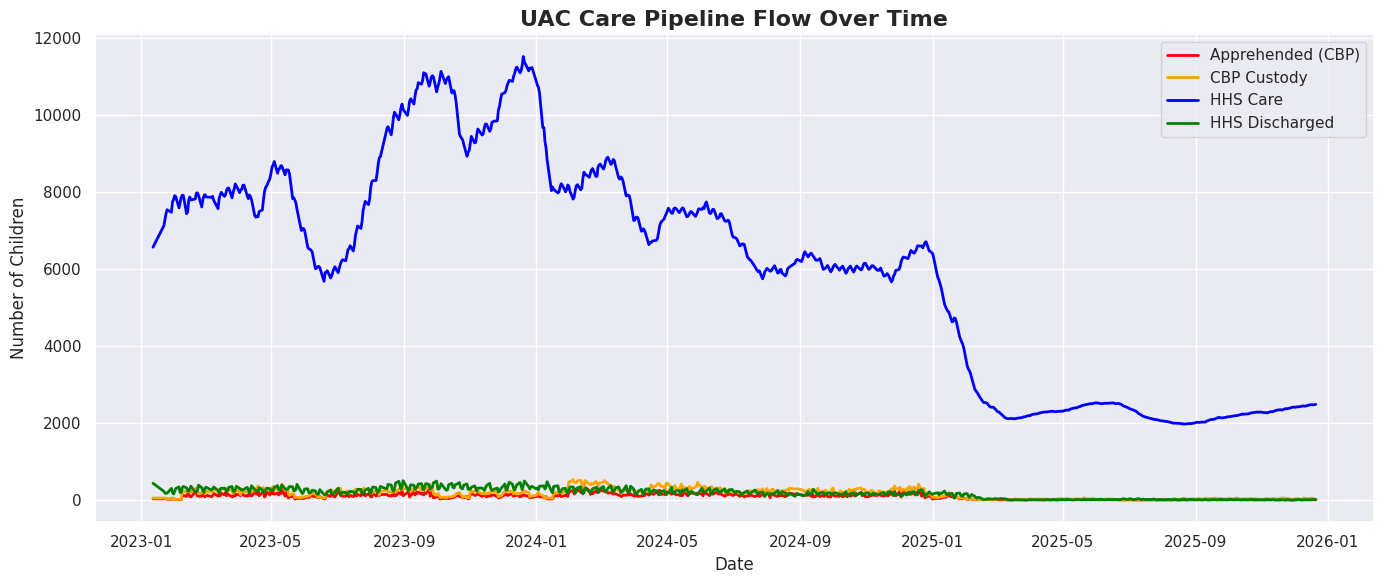

Chart Saved ✅


In [7]:
plt.figure(figsize=(14,6))
plt.plot(df['Date'], df['Apprehended'], label='Apprehended (CBP)', color='red', linewidth=2)
plt.plot(df['Date'], df['CBP_Custody'], label='CBP Custody', color='orange', linewidth=2)
plt.plot(df['Date'], df['HHS_Care'], label='HHS Care', color='blue', linewidth=2)
plt.plot(df['Date'], df['HHS_Discharged'], label='HHS Discharged', color='green', linewidth=2)
plt.title('UAC Care Pipeline Flow Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Number of Children')
plt.legend()
plt.tight_layout()
plt.savefig('pipeline_flow.png', dpi=150)
plt.show()
print("Chart Saved ✅")

## Backlog Analysis

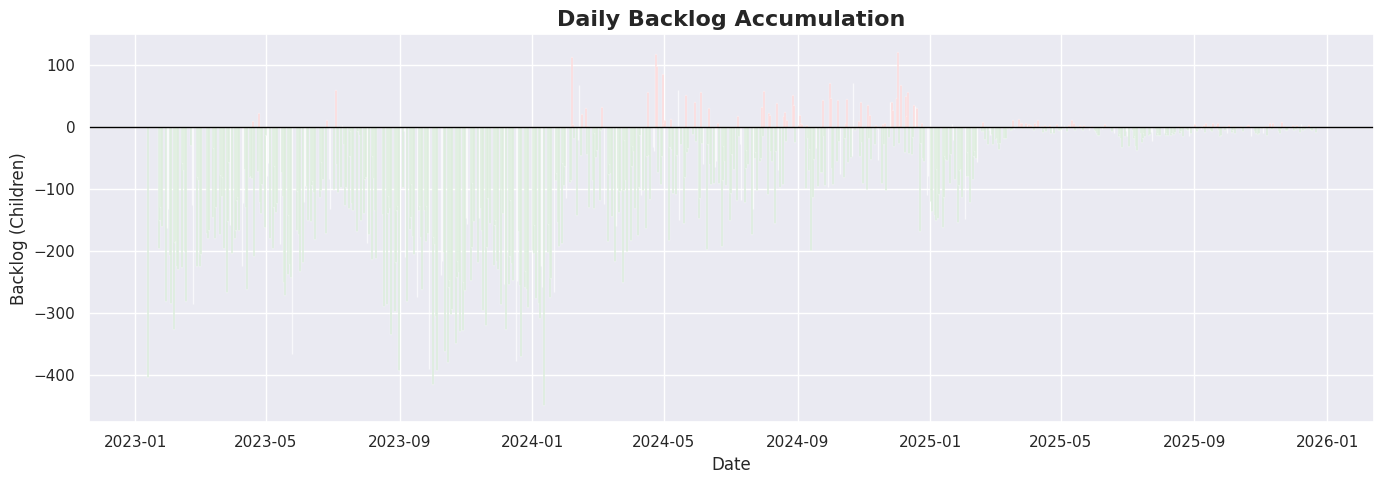

In [8]:
plt.figure(figsize=(14,5))
colors = ['red' if x > 0 else 'green' for x in df['Backlog']]
plt.bar(df['Date'], df['Backlog'], color=colors, alpha=0.7)
plt.axhline(y=0, color='black', linewidth=1)
plt.title('Daily Backlog Accumulation', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Backlog (Children)')
plt.tight_layout()
plt.savefig('backlog.png', dpi=150)
plt.show()

## Monthly Trend Analysis

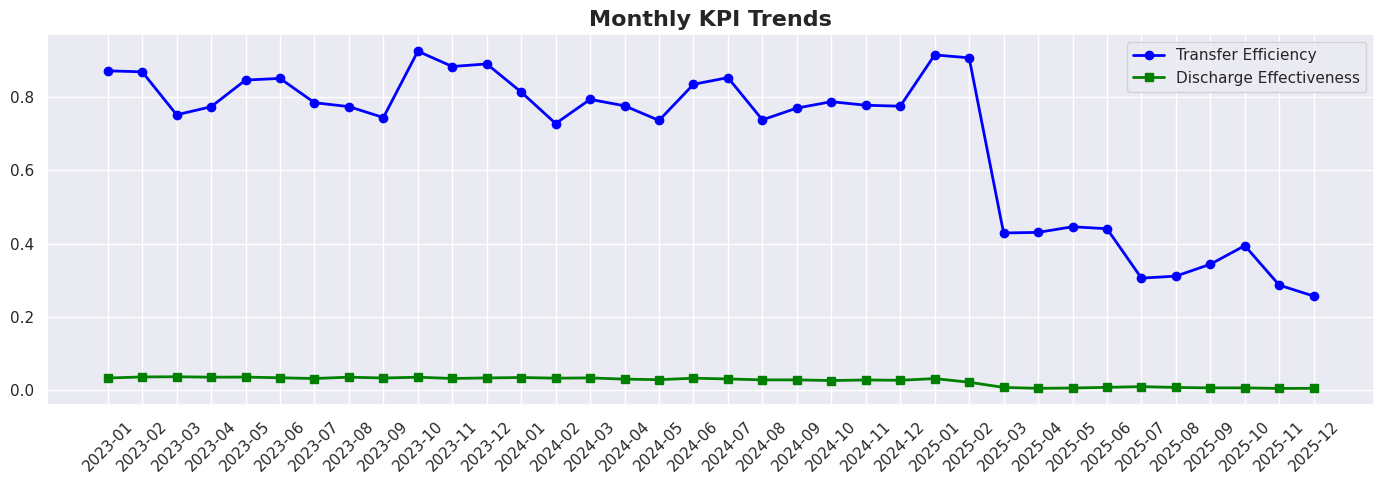

In [9]:
df['Month'] = df['Date'].dt.to_period('M')
monthly = df.groupby('Month').agg({
    'Apprehended': 'sum',
    'HHS_Discharged': 'sum',
    'Transfer_Efficiency': 'mean',
    'Discharge_Effectiveness': 'mean',
    'Backlog': 'mean'
}).reset_index()

monthly['Month'] = monthly['Month'].astype(str)

plt.figure(figsize=(14,5))
plt.plot(monthly['Month'], monthly['Transfer_Efficiency'], 
         marker='o', color='blue', linewidth=2, label='Transfer Efficiency')
plt.plot(monthly['Month'], monthly['Discharge_Effectiveness'], 
         marker='s', color='green', linewidth=2, label='Discharge Effectiveness')
plt.xticks(rotation=45)
plt.title('Monthly KPI Trends', fontsize=16, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('monthly_trends.png', dpi=150)
plt.show()

## Weekday vs Weekend Analysis

=== WEEKDAY vs WEEKEND TRANSFER EFFICIENCY ===
IsWeekend
Weekday    0.689020
Weekend    0.700083
Name: Transfer_Efficiency, dtype: float64


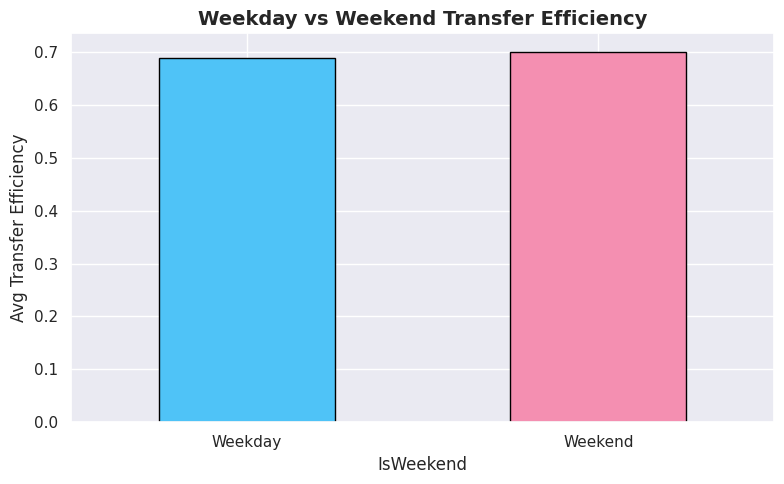

In [10]:
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['IsWeekend'] = df['DayOfWeek'].apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

weekend_analysis = df.groupby('IsWeekend')['Transfer_Efficiency'].mean()
print("=== WEEKDAY vs WEEKEND TRANSFER EFFICIENCY ===")
print(weekend_analysis)

plt.figure(figsize=(8,5))
weekend_analysis.plot(kind='bar', color=['#4fc3f7','#f48fb1'], edgecolor='black')
plt.title('Weekday vs Weekend Transfer Efficiency', fontsize=14, fontweight='bold')
plt.ylabel('Avg Transfer Efficiency')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('weekday_weekend.png', dpi=150)
plt.show()

## Corelation Heatmap

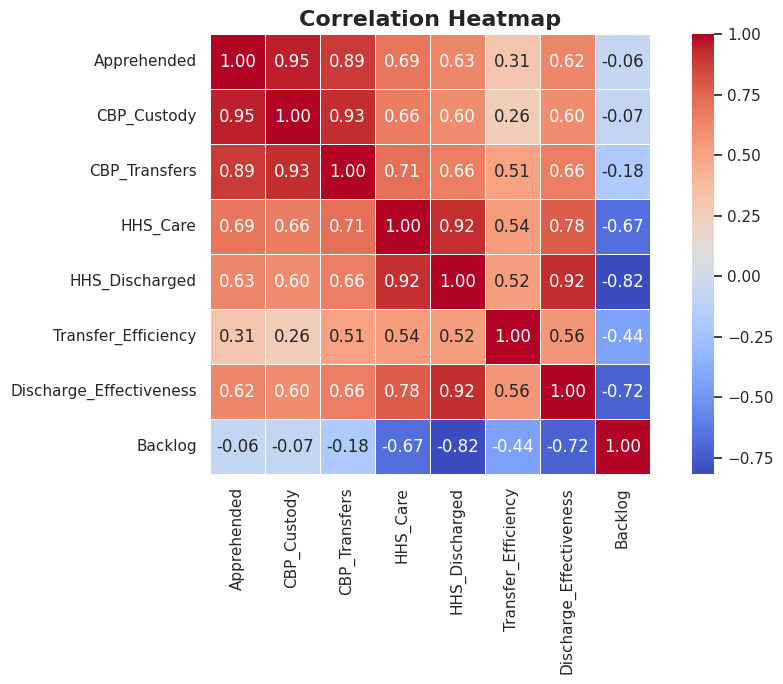

In [11]:
plt.figure(figsize=(10,7))
corr = df[['Apprehended','CBP_Custody','CBP_Transfers',
           'HHS_Care','HHS_Discharged','Transfer_Efficiency',
           'Discharge_Effectiveness','Backlog']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', 
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation.png', dpi=150)
plt.show()

In [12]:
print("=== BOTTLENECK ANALYSIS ===")
threshold = df['Backlog'].mean() + df['Backlog'].std()
bottlenecks = df[df['Backlog'] > threshold][['Date','Backlog','Transfer_Efficiency']]
print(f"Total Bottleneck Days: {len(bottlenecks)}")
print(f"Threshold: {threshold:.0f} children")
print("\nTop 10 Worst Bottleneck Days:")
print(bottlenecks.sort_values('Backlog', ascending=False).head(10).to_string(index=False))

=== BOTTLENECK ANALYSIS ===
Total Bottleneck Days: 45
Threshold: 18 children

Top 10 Worst Bottleneck Days:
      Date  Backlog  Transfer_Efficiency
2024-12-02    121.0             0.672727
2024-04-23    118.0             0.718970
2024-02-06    113.0             0.709890
2024-04-24     99.0             0.746959
2024-04-30     85.0             0.437923
2024-09-30     71.0             0.645614
2024-10-22     71.0             0.521429
2024-12-05     68.0             0.734982
2024-02-13     67.0             0.945799
2023-07-04     60.0             0.691083


## Final Summary

In [13]:
print("=" * 50)
print("   UAC CARE PIPELINE - FINAL INSIGHTS")
print("=" * 50)
print(f"\n📊 Total Records Analyzed: {len(df)}")
print(f"📅 Date Range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"\n🔄 Avg Transfer Efficiency:     {df['Transfer_Efficiency'].mean():.2%}")
print(f"✅ Avg Discharge Effectiveness: {df['Discharge_Effectiveness'].mean():.2%}")
print(f"⚠️  Avg Daily Backlog:           {df['Backlog'].mean():.0f} children")
print(f"🚀 Avg Pipeline Throughput:     {df['Pipeline_Throughput'].mean():.2%}")
print(f"\n🚨 Bottleneck Days Found:       {len(bottlenecks)}")
print(f"\n✅ EDA Complete!")

   UAC CARE PIPELINE - FINAL INSIGHTS

📊 Total Records Analyzed: 720
📅 Date Range: 2023-01-12 to 2025-12-21

🔄 Avg Transfer Efficiency:     69.10%
✅ Avg Discharge Effectiveness: 2.37%
⚠️  Avg Daily Backlog:           -80 children
🚀 Avg Pipeline Throughput:     inf%

🚨 Bottleneck Days Found:       45

✅ EDA Complete!
